# Inference: Anomaly Detection — deZem

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from src import load_dezem_csv, load_checkpoint, detect

/home/justmouheb/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Model

In [2]:
CSV_PATH = "../../assets/data/deZem/Dezem 2 years.csv"
WINDOW_SIZE = 24
STRIDE = 1

train_loader, val_loader, meta = load_dezem_csv(
    CSV_PATH,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    train_split=0.8,
    batch_size=64,
)

print(f"Features:      {meta['n_features']}")
print(f"Total points:  {meta['n_total']:,}")
print(f"Train windows: {meta['n_train']:,}")
print(f"Val windows:   {meta['n_val']:,}")
print(f"Date range:    {meta['index'][0]} → {meta['index'][-1]}")

Dropping 2 duplicate timestamps (keeping first)
Filling 74 missing hourly timestamps via time interpolation
Loaded 16,704 hourly points
Range: [0.59, 1453.01]  Mean: 164.88  Std: 244.29
Windows — train: 13,340  val: 3,318  (window=24h, stride=1)
Features:      1
Total points:  16,704
Train windows: 13,340
Val windows:   3,318
Date range:    2023-01-01 00:00:00 → 2024-11-26 23:00:00


In [3]:
CHECKPOINT = "../../checkpoints/dezem/lightweight/best_model.pt"

model = load_checkpoint(
    CHECKPOINT,
    model_type="lightweight",
    input_dim=meta["n_features"],
    preset="pico",
)

/home/justmouheb/AI-dezem/anomaly-transformer/src/models/model.py:211: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Loaded checkpoint (epoch 24, val_loss 0.000411)


## 2. Reconstruction Quality (no labels)

Score every window in the **full** series to get a dense anomaly signal.

In [4]:
# Stack all windows (train + val) for full-series scoring
all_windows = np.concatenate(
    [np.concatenate([b[0].numpy() for b in loader], axis=0)
     for loader in [train_loader, val_loader]],
    axis=0,
)  # [N, window_size, 1]

print(f"Total windows to score: {len(all_windows):,}")

Total windows to score: 16,630


## 3. Detect Anomalies

In [5]:
# train_split=0.8 → threshold fitted on first 80% of windows ("normal" assumption)
results = detect(
    model,
    all_windows,
    threshold_method="gaussian",   # mu + 3*sigma
    train_split=0.8,
)

scores    = results["scores"]       # per-window reconstruction error
anomalies = results["anomalies"]    # boolean mask
threshold = results["threshold"]

print(f"Threshold:    {threshold:.6f}  ({results['threshold_info']['method']})")
print(f"Anomalies:    {results['n_anomalies']:,} / {len(scores):,} windows")
print(f"Anomaly rate: {results['anomaly_rate'] * 100:.2f}%")
print(f"Score stats   mean={scores.mean():.4f}  std={scores.std():.4f}  "
      f"p95={np.percentile(scores, 95):.4f}  max={scores.max():.4f}")

Threshold:    0.027847  (gaussian)
Anomalies:    219 / 16,630 windows
Anomaly rate: 1.32%
Score stats   mean=0.0098  std=0.0060  p95=0.0208  max=0.0668


## 4. Visualize

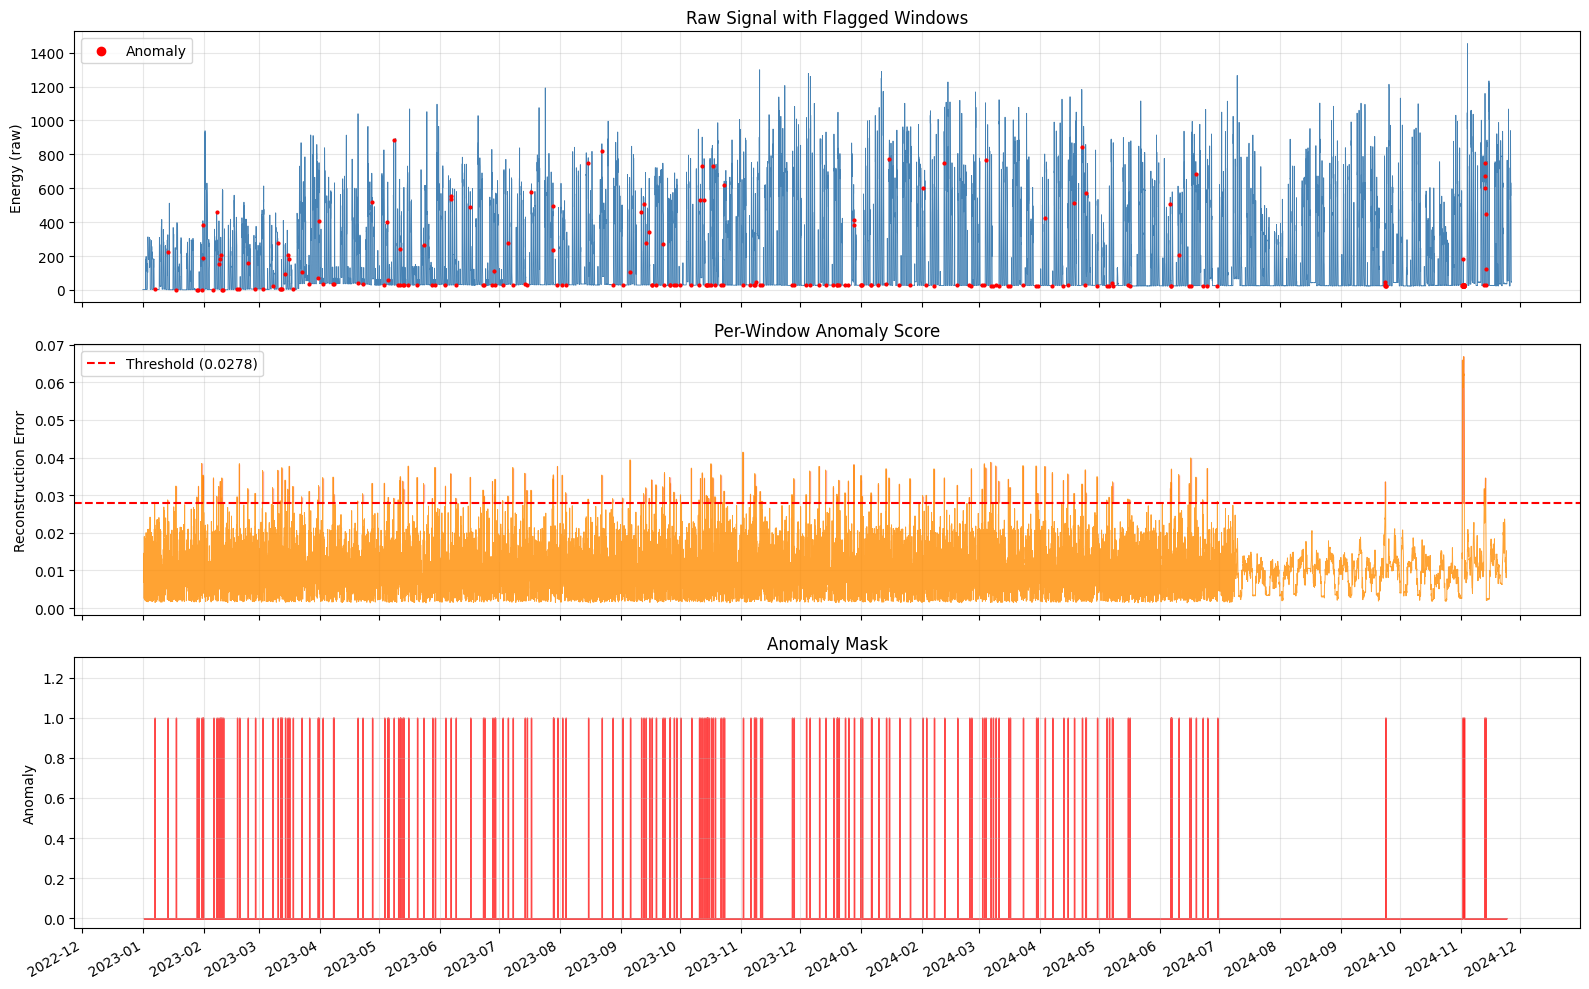

In [6]:
# Map window index → timestamp of the window's last point
ts = meta["index"]  # full hourly DatetimeIndex
# Each window i covers ts[i : i + WINDOW_SIZE]; anchor at centre
win_times = ts[WINDOW_SIZE // 2 : WINDOW_SIZE // 2 + len(scores)]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# ── raw signal ──
axes[0].plot(ts, meta["values_raw"], linewidth=0.6, color="steelblue")
# shade anomalous periods
if anomalies.any():
    anom_times = win_times[anomalies]
    axes[0].scatter(anom_times, meta["values_raw"][WINDOW_SIZE // 2 : WINDOW_SIZE // 2 + len(scores)][anomalies],
                    c="red", s=4, zorder=3, label="Anomaly")
axes[0].set_ylabel("Energy (raw)")
axes[0].set_title("Raw Signal with Flagged Windows")
axes[0].legend(markerscale=3)
axes[0].grid(True, alpha=0.3)

# ── anomaly score ──
axes[1].plot(win_times, scores, linewidth=0.7, color="darkorange", alpha=0.8)
axes[1].axhline(threshold, color="red", ls="--", lw=1.5, label=f"Threshold ({threshold:.4f})")
axes[1].fill_between(win_times, scores, threshold, where=anomalies, alpha=0.35, color="red")
axes[1].set_ylabel("Reconstruction Error")
axes[1].set_title("Per-Window Anomaly Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── anomaly binary ──
axes[2].fill_between(win_times, anomalies.astype(float), alpha=0.7, color="red", step="mid")
axes[2].set_ylabel("Anomaly")
axes[2].set_title("Anomaly Mask")
axes[2].set_ylim(-0.05, 1.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].grid(True, alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

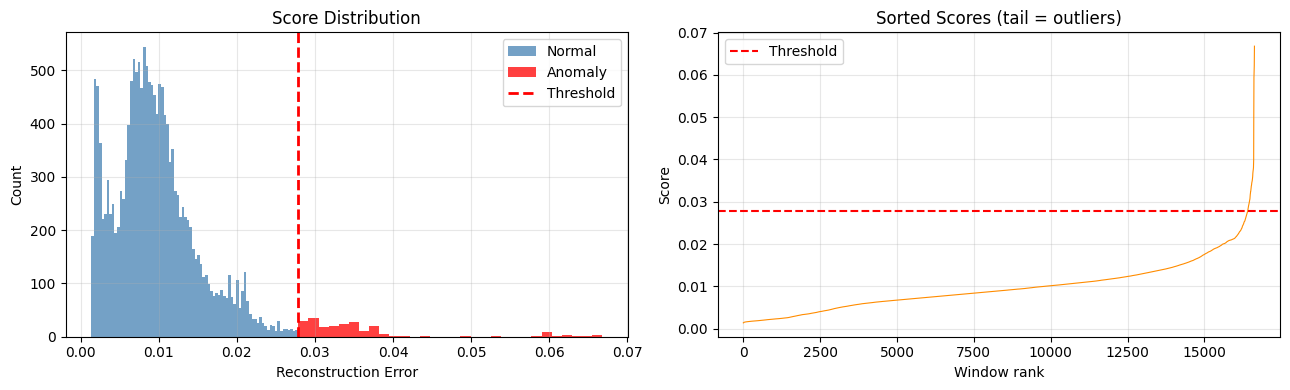

In [7]:
# Score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(scores[~anomalies], bins=80, alpha=0.75, color="steelblue", label="Normal")
axes[0].hist(scores[anomalies],  bins=30, alpha=0.75, color="red",       label="Anomaly")
axes[0].axvline(threshold, color="red", ls="--", lw=2, label=f"Threshold")
axes[0].set_xlabel("Reconstruction Error")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q style: sorted scores
sorted_scores = np.sort(scores)
axes[1].plot(sorted_scores, linewidth=0.8, color="darkorange")
axes[1].axhline(threshold, color="red", ls="--", lw=1.5, label="Threshold")
axes[1].set_xlabel("Window rank")
axes[1].set_ylabel("Score")
axes[1].set_title("Sorted Scores (tail = outliers)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Top anomalous periods
top_n = 10
top_idx = np.argsort(scores)[::-1][:top_n]
print(f"Top {top_n} anomalous windows:")
print(f"{'Rank':<5} {'Timestamp':<25} {'Score':>10}")
print("-" * 42)
for rank, idx in enumerate(top_idx, 1):
    t = win_times[idx] if idx < len(win_times) else "?"
    print(f"{rank:<5} {str(t):<25} {scores[idx]:>10.5f}")

Top 10 anomalous windows:
Rank  Timestamp                      Score
------------------------------------------
1     2024-11-02 15:00:00          0.06679
2     2024-11-02 14:00:00          0.06662
3     2024-11-02 16:00:00          0.06598
4     2024-11-02 00:00:00          0.06585
5     2024-11-02 13:00:00          0.06487
6     2024-11-02 01:00:00          0.06353
7     2024-11-02 18:00:00          0.06218
8     2024-11-02 12:00:00          0.06207
9     2024-11-02 17:00:00          0.06180
10    2024-11-02 02:00:00          0.06164


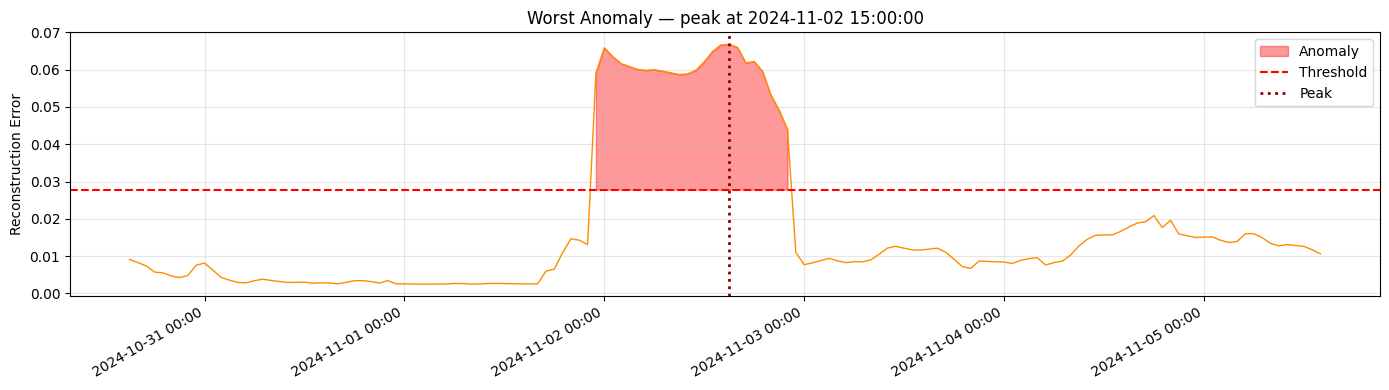

In [9]:
# Zoom into the single worst anomaly
worst = int(np.argmax(scores))
pad = 72  # hours of context either side
lo = max(0, worst - pad)
hi = min(len(scores) - 1, worst + pad)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(win_times[lo:hi], scores[lo:hi], color="darkorange", linewidth=1)
ax.fill_between(win_times[lo:hi], scores[lo:hi], threshold,
                where=anomalies[lo:hi], alpha=0.4, color="red", label="Anomaly")
ax.axhline(threshold, color="red", ls="--", lw=1.5, label="Threshold")
ax.axvline(win_times[worst], color="darkred", ls=":", lw=2, label="Peak")
ax.set_title(f"Worst Anomaly — peak at {win_times[worst]}")
ax.set_ylabel("Reconstruction Error")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=30, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()